![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Geospatial & Spatial Epidemiology


# Health Service Area & Access Metrics



**Learning objectives**
- Compute travel distance and catchment-area access metrics
- Implement the Two-Step Floating Catchment Area (2SFCA) method
- Build provider-to-population ratio metrics by service area
- Delineate Health Professional Shortage Areas (HPSA-style analysis)
- Compute network accessibility indices for hospital and primary care
- Map spatial disparities in healthcare access

**Estimated time:** 2.5 hours | **Level:** Advanced  
**Libraries:** `numpy`, `scipy`, `pandas`, `matplotlib`


## 1. Setup

This notebook simulates and visualizes county-level cardiovascular disease (CVD) rates and health service access across US counties using real county geography. It begins by importing geospatial and numerical libraries, reading in shapefile and demographic data, and preparing a geodataframe indexed by county. Each county is assigned simulated values for sociodemographic variables (such as poverty rate, uninsured rate, PM2.5 air pollution, and population) using statistical distributions and spatial patterns. CVD rates are then generated as a function of these covariates and spatially-smoothed random effects, and both expected and observed CVD case counts are simulated. The code further generates synthetic hospital locations, types, and bed counts by sampling from counties in proportion to population and adding local spatial jitter. Both the county and hospital datasets are saved as CSV files for later analysis. Finally, the simulated fields, demographics, outcomes, spatial risk, and hospital distribution, are visualized as choropleth and scatter maps overlaid on the US map, setting the stage for spatial epidemiology and health access analysis.

N=3108 counties | 300 hospitals | CVD=217.1/100k
  poverty 14.8% | uninsured 14.4% | PM2.5 16.0 | SMR mean 1.00


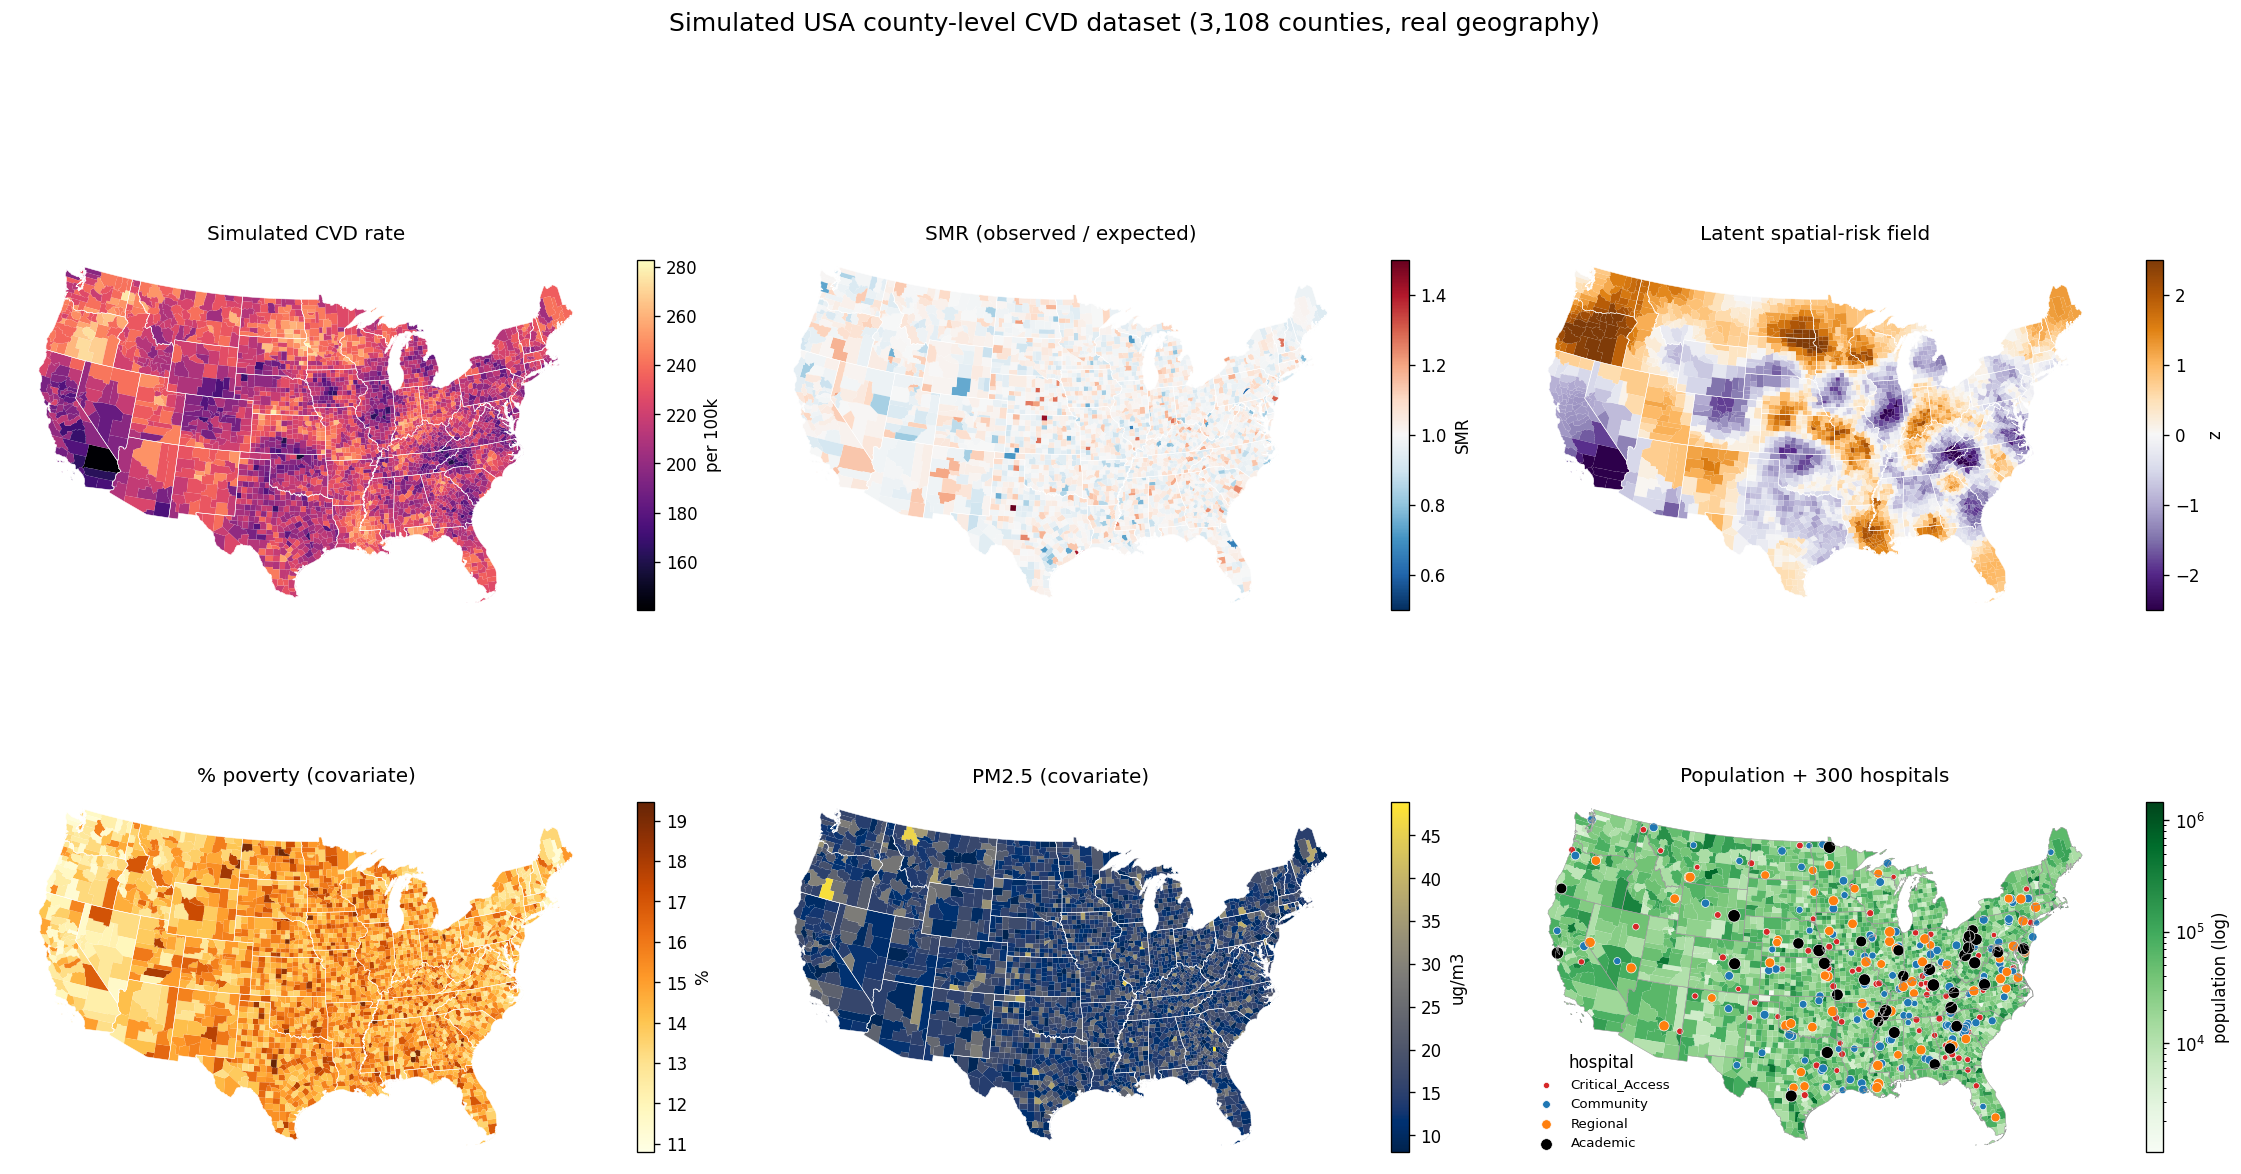

In [1]:
"""Port of the grid CVD simulation onto real US county geography."""
import numpy as np, pandas as pd, geopandas as gpd, warnings, os
from scipy.spatial import cKDTree
from pyproj import Transformer
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
warnings.filterwarnings("ignore"); os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
np.random.seed(42)

# ---- real county geography ------------------------------------------------ #
rawcsv = pd.read_csv("Data/usa_data.csv"); rawcsv["fips"] = rawcsv.fips.astype(int)
shp = gpd.read_file("Data/US_COUNTY.shp")
shp["FIPS"] = shp["FIPS"].astype(int).replace({46113: 46102})
gdf = shp.merge(rawcsv, left_on="FIPS", right_on="fips", how="inner").reset_index(drop=True)
N = len(gdf)
xy = np.c_[gdf.geometry.centroid.x.values, gdf.geometry.centroid.y.values]      # Albers metres
lon, lat = Transformer.from_crs(5070, 4326, always_xy=True).transform(xy[:, 0], xy[:, 1])

# ---- real-geography spatial smoother (replaces grid gaussian_filter) ------ #
tree = cKDTree(xy)
def sp(vals, bw=200_000.0, k=60):
    d, idx = tree.query(xy, k=k)
    w = np.exp(-(d ** 2) / (2 * bw ** 2))
    out = (vals[idx] * w).sum(1) / w.sum(1)
    return (out - out.mean()) / out.std()

# ---- covariates (your generative model, on real lon/lat) ------------------ #
pct_poverty  = 10 + 8 * np.random.beta(2, 5, N) + 3 * np.sin(lon / 20)
pct_uninsured = 8 + 6 * np.random.beta(2, 4, N) + 0.3 * pct_poverty
pm25 = 8 + 4 * np.random.gamma(2, 1, N)
population = np.random.lognormal(10.5, 1.0, N).astype(int)
spatial_risk = sp(np.random.normal(0, 1, N))
cvd_rate = (180 + 1.2 * pct_poverty + 0.8 * pct_uninsured + 0.5 * pm25
            + 15 * spatial_risk + np.random.normal(0, 12, N))
expected = (cvd_rate / 100000) * population * 5
observed = np.random.poisson(expected).astype(int)
smr = observed / expected.clip(1)

df = pd.DataFrame({
    "county_id": gdf.fips.astype(str).str.zfill(5), "fips": gdf.fips.astype(int),
    "county": gdf.county, "state_abbr": gdf.state_abbr,
    "lon": lon, "lat": lat, "x_m": xy[:, 0], "y_m": xy[:, 1],
    "pct_poverty": pct_poverty, "pct_uninsured": pct_uninsured, "pm25": pm25,
    "population": population, "cvd_rate": cvd_rate,
    "observed": observed, "expected": expected, "smr": smr})

# ---- hospitals (placed at population-weighted county sites) ---------------- #
np.random.seed(5); N_HOSP = 300
pick = np.random.choice(N, N_HOSP, replace=True, p=population / population.sum())
jit = np.random.normal(0, 15000, (N_HOSP, 2))
h_lon, h_lat = Transformer.from_crs(5070, 4326, always_xy=True).transform(
    xy[pick, 0] + jit[:, 0], xy[pick, 1] + jit[:, 1])
hosp_type = np.random.choice(["Critical_Access", "Community", "Regional", "Academic"],
                             N_HOSP, p=[0.30, 0.40, 0.20, 0.10])
hosp_beds = np.where(hosp_type == "Academic", np.random.randint(400, 800, N_HOSP),
            np.where(hosp_type == "Regional", np.random.randint(150, 400, N_HOSP),
            np.where(hosp_type == "Community", np.random.randint(50, 200, N_HOSP),
                     np.random.randint(25, 75, N_HOSP))))
df_hosp = pd.DataFrame({"lon": h_lon, "lat": h_lat, "type": hosp_type, "beds": hosp_beds,
                        "x_m": xy[pick, 0] + jit[:, 0], "y_m": xy[pick, 1] + jit[:, 1]})

print(f"N={N} counties | {N_HOSP} hospitals | CVD={cvd_rate.mean():.1f}/100k")
print(f"  poverty {pct_poverty.mean():.1f}% | uninsured {pct_uninsured.mean():.1f}% | "
      f"PM2.5 {pm25.mean():.1f} | SMR mean {smr.mean():.2f}")
df.to_csv("Data/usa_county_sim.csv", index=False)
df_hosp.to_csv("Data/usa_hospitals_sim.csv", index=False)

# ---- visualise the simulated fields --------------------------------------- #
gsim = gdf[["geometry"]].copy()
for c in ["cvd_rate", "smr", "pct_poverty", "pm25", "population"]:
    gsim[c] = df[c].values
gsim["spatial_risk"] = spatial_risk
states = gdf.dissolve("STATE")
fig, ax = plt.subplots(2, 3, figsize=(19, 11))
def choro(a, col, title, cmap="viridis", norm=None, cbar=""):
    gsim.plot(ax=a, column=col, cmap=cmap, norm=norm, legend=True,
              legend_kwds={"label": cbar, "shrink": 0.5}, edgecolor="none")
    states.boundary.plot(ax=a, color="white", lw=0.3)
    a.set_title(title, fontsize=12); a.set_aspect("equal"); a.axis("off")
choro(ax[0,0], "cvd_rate", "Simulated CVD rate", "magma", cbar="per 100k")
choro(ax[0,1], "smr", "SMR (observed / expected)", "RdBu_r",
      TwoSlopeNorm(vmin=0.5, vcenter=1, vmax=1.5), "SMR")
choro(ax[0,2], "spatial_risk", "Latent spatial-risk field", "PuOr_r",
      TwoSlopeNorm(vmin=-2.5, vcenter=0, vmax=2.5), "z")
choro(ax[1,0], "pct_poverty", "% poverty (covariate)", "YlOrBr", cbar="%")
choro(ax[1,1], "pm25", "PM2.5 (covariate)", "cividis", cbar="ug/m3")
# population + hospitals
gsim.plot(ax=ax[1,2], column="population", cmap="Greens",
          norm=LogNorm(population.min()+1, population.max()), edgecolor="none",
          legend=True, legend_kwds={"label": "population (log)", "shrink": 0.5})
states.boundary.plot(ax=ax[1,2], color="0.6", lw=0.3)
tcol = {"Critical_Access": "#d62728", "Community": "#1f77b4",
        "Regional": "#ff7f0e", "Academic": "#000000"}
for t, c in tcol.items():
    s = df_hosp[df_hosp.type == t]
    ax[1,2].scatter(s.x_m, s.y_m, s=np.sqrt(s.beds)*2, c=c, edgecolors="white",
                    linewidths=0.4, label=t)
ax[1,2].legend(loc="lower left", fontsize=8, frameon=False, title="hospital")
ax[1,2].set_title("Population + 300 hospitals", fontsize=12)
ax[1,2].set_aspect("equal"); ax[1,2].axis("off")
fig.suptitle("Simulated USA county-level CVD dataset (3,108 counties, real geography)",
             fontsize=15, y=1.01)
fig.tight_layout()


## 2. Access Metrics Framework

**Primary Care Access Metrics: Detailed Explanation**

Healthcare access can be quantified by several metrics, each capturing different aspects of spatial access to health services:

| Metric                        | Formula / Calculation                                                           | Key Limitation                                                                                                                  |
|-------------------------------|----------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------|
| **Provider:population ratio** | Number of providers divided by population in a given area (e.g., beds per 1000 people) | Does not consider where providers or people are spatially located; ignores distance or travel barriers.                        |
| **Distance to nearest**       | Minimum distance ($\min(d_{ij})$) from population centroid $i$ to the closest provider $j$  | Considers spatial location, but ignores number of providers (capacity) and population demand.                                   |
| **2SFCA (Two-Step Floating Catchment Area)** | For each area: sum of accessible provider-to-population ratios using spatial catchments        | Comprehensive, but may require more data and computation. Accounts for both distance and capacity.                              |
| **Gravity model**             | Accessibility = $\sum\limits_j \dfrac{S_j}{d_{ij}^p}$ <br>where $S_j$ is provider supply, $d_{ij}$ is distance, and $p$ is a decay parameter | Sensitive to choice of distance-decay parameter; requires calibration.                                                         |
| **Floating catchment**        | Areas and providers are "linked" if within a fixed catchment radius (e.g., within $d$ miles) | Binary inclusion: everyone within catchment is treated equally, so it ignores gradual changes over distance.                   |

**Details on Two-Step Floating Catchment Area (2SFCA) Method:**

This method estimates spatial accessibility by considering both the supply of providers (e.g., hospital beds) and the demand (population) within a catchment radius, factoring in distance for both.

1. **Step 1 (Provider Perspective):**
    - For each provider location $j$, define a catchment area (e.g., within $d$ miles).
    - Calculate the provider-to-population ratio:  
      $$
      R_j = \frac{\text{Beds}_j}{\sum\limits_i \text{Pop}_i}
      $$
      where the sum is over all $i$ (population locations) within the provider's catchment.

2. **Step 2 (Population Perspective):**
    - For each population location $i$, identify all providers $j$ within its catchment.
    - Compute the accessibility index:  
      $$
      A_i = \sum\limits_j R_j
      $$
      for all $j$ within the catchment of $i$. Optionally, distance-based weights can be applied.

- Higher values of $A_i$ indicate better access to providers.
- Extensions can use distance-decay weighting, variable catchment sizes, or account for provider type/capacity.


Access metrics computed:
  Beds per 1000 (simple PPR): mean=294.68 SD=494.92
  Distance to nearest hospital: mean=0.82 deg SD=0.64 deg
  2SFCA access score: mean=0.0003 SD=0.0004

  corr(2SFCA, CVD rate)      = -0.009
  corr(dist nearest, CVD)    = +0.025
  counties with 0 hospitals in catchment: 2


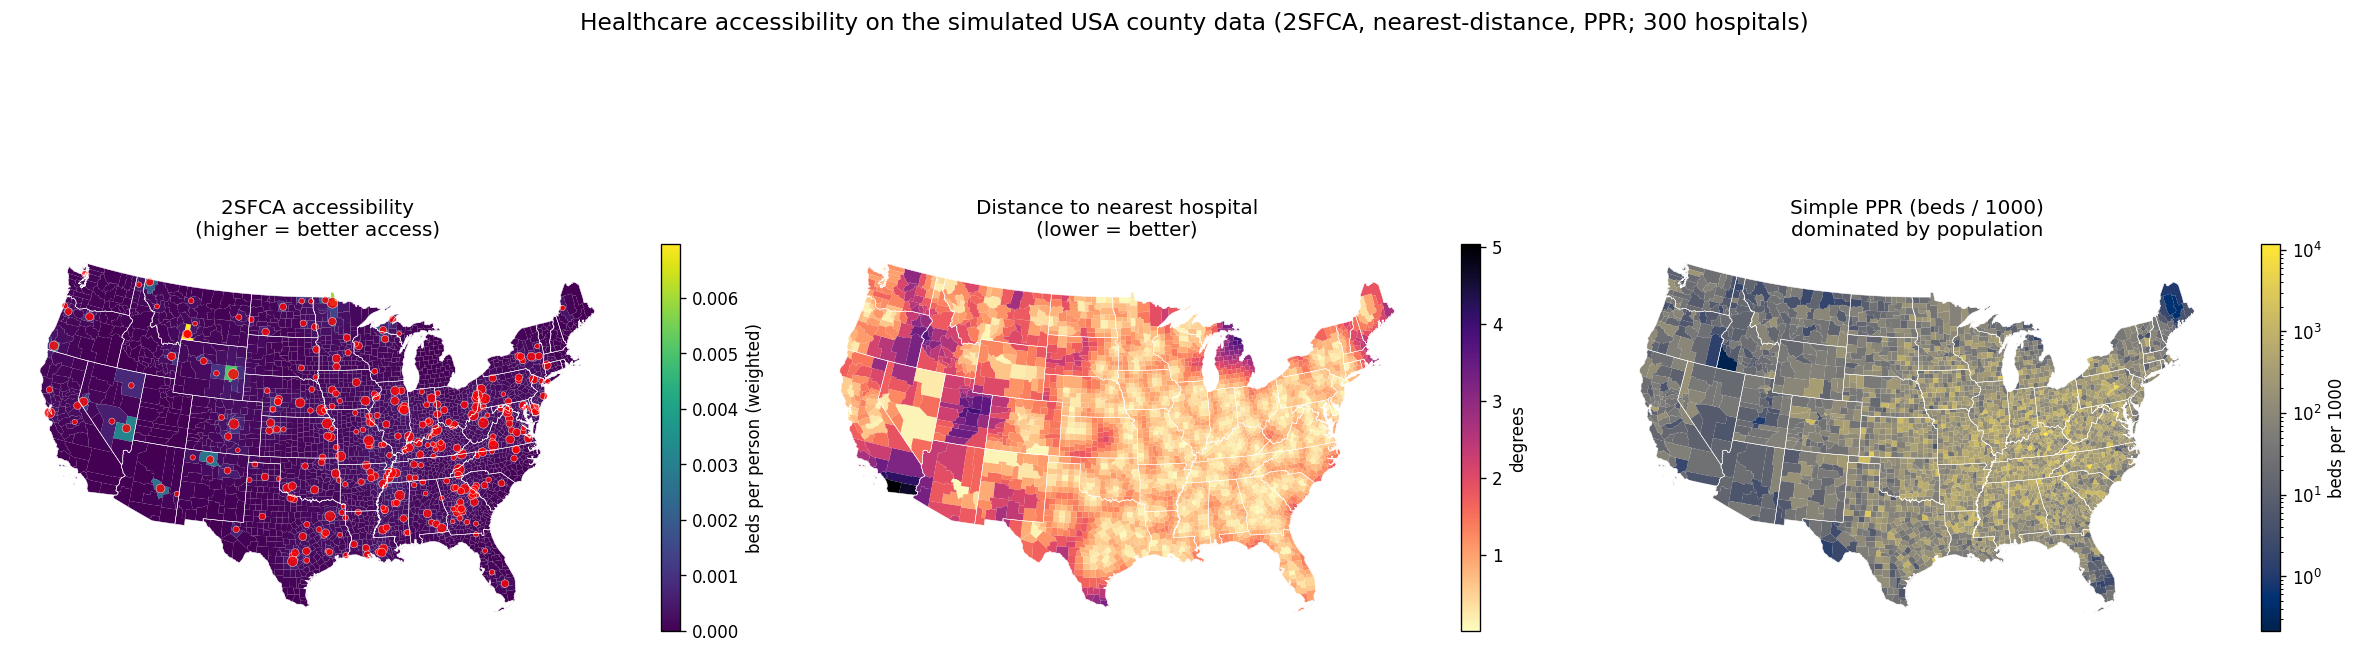

In [2]:
import numpy as np, pandas as pd, geopandas as gpd, warnings, os
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
warnings.filterwarnings("ignore"); os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})

df = pd.read_csv("Data/usa_county_sim.csv")
df_hosp = pd.read_csv("Data/usa_hospitals_sim.csv")
N = len(df)

# ================== user's accessibility code =============================== #
county_coords = np.column_stack([df.lon, df.lat])
hosp_coords = np.column_stack([df_hosp.lon, df_hosp.lat])
tree_hosp = cKDTree(hosp_coords)
dist_matrix = cdist(county_coords, hosp_coords)          # (N_counties, N_hospitals)
CATCHMENT_DEG = 4.5                                       # ~5 deg ~ 300 miles

ppr = np.zeros(N)
for i in range(N):
    in_catchment = dist_matrix[i] <= CATCHMENT_DEG
    if in_catchment.any():
        total_beds = df_hosp.loc[in_catchment, "beds"].sum()
        ppr[i] = total_beds / (df.population.iloc[i] / 1000)
df["ppr_beds_per_1000"] = ppr
df["dist_nearest_hosp"] = dist_matrix.min(axis=1)

def two_sfca(county_pop, county_coords, provider_cap, provider_coords, catchment, decay_power=1):
    dist = cdist(county_coords, provider_coords)
    R_j = np.zeros(len(provider_cap))
    for j in range(len(provider_cap)):
        in_zone = dist[:, j] <= catchment
        denom = (county_pop[in_zone] / (dist[in_zone, j] + 0.1) ** decay_power).sum()
        R_j[j] = provider_cap[j] / denom if denom > 0 else 0
    A_i = np.zeros(len(county_pop))
    for i in range(len(county_pop)):
        in_zone = dist[i, :] <= catchment
        if in_zone.any():
            weights = 1 / (dist[i, in_zone] + 0.1) ** decay_power
            A_i[i] = (R_j[in_zone] * weights).sum()
    return A_i

df["access_2sfca"] = two_sfca(df.population.values, county_coords,
                              df_hosp.beds.values, hosp_coords,
                              catchment=CATCHMENT_DEG, decay_power=2)
print("Access metrics computed:")
print(f"  Beds per 1000 (simple PPR): mean={df.ppr_beds_per_1000.mean():.2f} SD={df.ppr_beds_per_1000.std():.2f}")
print(f"  Distance to nearest hospital: mean={df.dist_nearest_hosp.mean():.2f} deg SD={df.dist_nearest_hosp.std():.2f} deg")
print(f"  2SFCA access score: mean={df.access_2sfca.mean():.4f} SD={df.access_2sfca.std():.4f}")
# ============================================================================ #

# correlations with need (CVD/SMR) — is access aligned with burden?
print(f"\n  corr(2SFCA, CVD rate)      = {np.corrcoef(df.access_2sfca, df.cvd_rate)[0,1]:+.3f}")
print(f"  corr(dist nearest, CVD)    = {np.corrcoef(df.dist_nearest_hosp, df.cvd_rate)[0,1]:+.3f}")
print(f"  counties with 0 hospitals in catchment: {(df.access_2sfca==0).sum()}")


# ---- maps ----------------------------------------------------------------- #
shp = gpd.read_file("Data/US_COUNTY.shp")
shp["FIPS"] = shp["FIPS"].astype(int).replace({46113: 46102})
g = shp.merge(df, left_on="FIPS", right_on="fips", how="inner").reset_index(drop=True)
states = g.dissolve("STATE"); hx, hy = df_hosp.x_m, df_hosp.y_m
fig, ax = plt.subplots(1, 3, figsize=(20, 6.5))
def choro(a, col, title, cmap, cbar, norm=None):
    g.plot(ax=a, column=col, cmap=cmap, norm=norm, legend=True,
           legend_kwds={"label": cbar, "shrink": 0.55}, edgecolor="none")
    states.boundary.plot(ax=a, color="white", lw=0.3)
    a.set_title(title, fontsize=12); a.set_aspect("equal"); a.axis("off")
choro(ax[0], "access_2sfca", "2SFCA accessibility\n(higher = better access)",
      "viridis", "beds per person (weighted)")
ax[0].scatter(hx, hy, s=np.sqrt(df_hosp.beds)*1.5, c="red", edgecolors="white",
              linewidths=0.3, alpha=0.8)
choro(ax[1], "dist_nearest_hosp", "Distance to nearest hospital\n(lower = better)",
      "magma_r", "degrees")
choro(ax[2], "ppr_beds_per_1000", "Simple PPR (beds / 1000)\ndominated by population",
      "cividis", "beds per 1000", LogNorm(max(df.ppr_beds_per_1000[df.ppr_beds_per_1000>0].min(),1e-2),
                                          df.ppr_beds_per_1000.max()))
fig.suptitle("Healthcare accessibility on the simulated USA county data "
             "(2SFCA, nearest-distance, PPR; 300 hospitals)", fontsize=14, y=1.02)
fig.tight_layout()



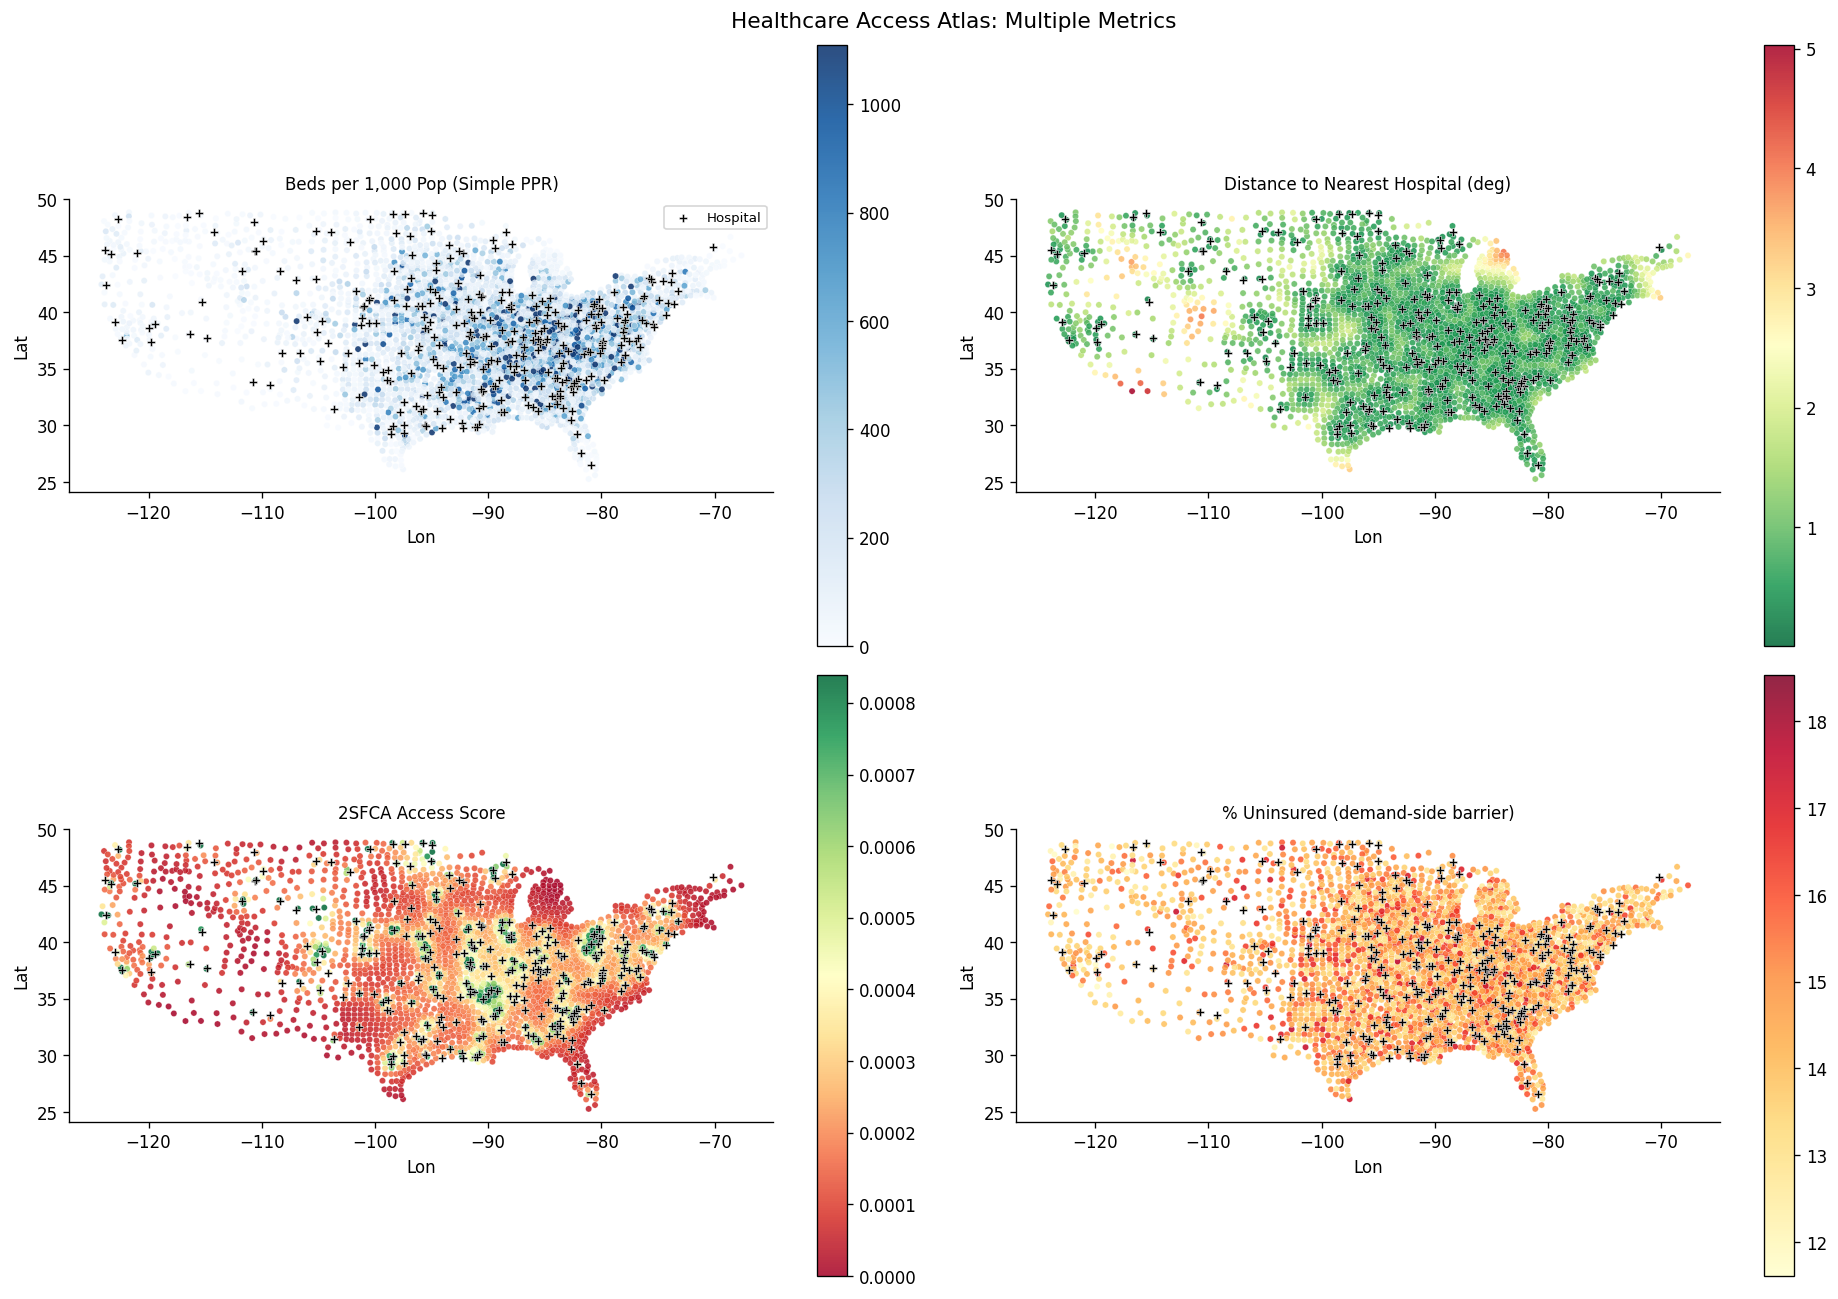

In [3]:
# Map access metrics

import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings, os
warnings.filterwarnings("ignore"); os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
 
 
# Map access metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
ax = axes.flatten()
S = 14   # (reduced from 150 for 3,108 counties)
 
for i, (col, title, cmap, invert) in enumerate([
    ("ppr_beds_per_1000",  "Beds per 1,000 Pop (Simple PPR)", "Blues", False),
    ("dist_nearest_hosp",  "Distance to Nearest Hospital (deg)", "RdYlGn_r", False),
    ("access_2sfca",       "2SFCA Access Score", "RdYlGn", False),
    ("pct_uninsured",      "% Uninsured (demand-side barrier)", "YlOrRd", False),
]):
    vals = df[col]
    # PPR and 2SFCA are strongly right-skewed -> clip colour scale so they read
    vmax = np.percentile(vals, 95) if col in ("ppr_beds_per_1000", "access_2sfca") else None
    sc = ax[i].scatter(df.lon, df.lat, c=vals, cmap=cmap, s=S, alpha=0.85,
                       edgecolors="white", linewidth=0.2, vmax=vmax)
    ax[i].scatter(df_hosp.lon, df_hosp.lat, marker="P", c="black", s=22, zorder=5,
                  edgecolors="white", linewidths=0.3, label="Hospital")
    plt.colorbar(sc, ax=ax[i]); ax[i].set_title(title, fontsize=10)
    ax[i].set_xlabel("Lon"); ax[i].set_ylabel("Lat"); ax[i].set_aspect("equal")
    if i == 0: ax[i].legend(fontsize=8)
plt.suptitle("Healthcare Access Atlas: Multiple Metrics", fontsize=13)
plt.tight_layout()

 


Reading across the four metrics: Simple PPR (top-left) is bright in the East and near-white through the interior West — but as noted last turn, that's mostly the population denominator talking, not real access. Distance to nearest hospital (top-right, red = far) shows the cleanest signal: green and accessible across the dense eastern half, redder through the sparse Mountain West and interior. 2SFCA (bottom-left, green = better) confirms it — access concentrates around the hospital clusters in the eastern and central US and collapses to red in the West where hospitals thin out. % uninsured (bottom-right) is the demand-side barrier, and because it was simulated as a function of poverty with a mild east-west gradient it doesn't align with the supply metrics — which is the point of putting it in the same atlas: a county can have decent physical access and still face a coverage barrier, or vice versa.

Two adjustments from your original for county scale: I dropped the marker size from 150 to 14 (150 was tuned for the 200-cell grid and turned into overlapping blobs at 3,108 counties) and shrank the hospital markers so they stopped burying the eastern counties. I also clipped the PPR and 2SFCA color scales at the 95th percentile — both are strongly right-skewed, so on a raw linear scale nearly every county rendered the same dark color and the spatial pattern vanished; the clip lets the variation show.

## 3. HPSA-Style Shortage Area Delineation

In this section, we apply HPSA-style (Health Professional Shortage Area) shortage area delineation to assess areas that face limited access to healthcare services. HPSA designation typically identifies regions with insufficient healthcare providers or other barriers, using criteria such as low provider-to-population ratios, significant distances to the nearest healthcare facility, low spatial accessibility scores, and high rates of uninsured populations.  By combining multiple metrics into a composite shortage score, we classify each area into levels of healthcare access: from "Adequate" to "HPSA" (most severe shortage). We also visualize these results spatially and summarize the proportion of the population falling into each category.

HPSA Analysis Summary:
  Adequate              :  18 counties | 177,559 residents (0.1%)
  Low shortage          : 664 counties | 24,614,527 residents (13.2%)
  Moderate shortage     : 1531 counties | 102,652,444 residents (54.9%)
  HPSA                  : 895 counties | 59,594,972 residents (31.9%)


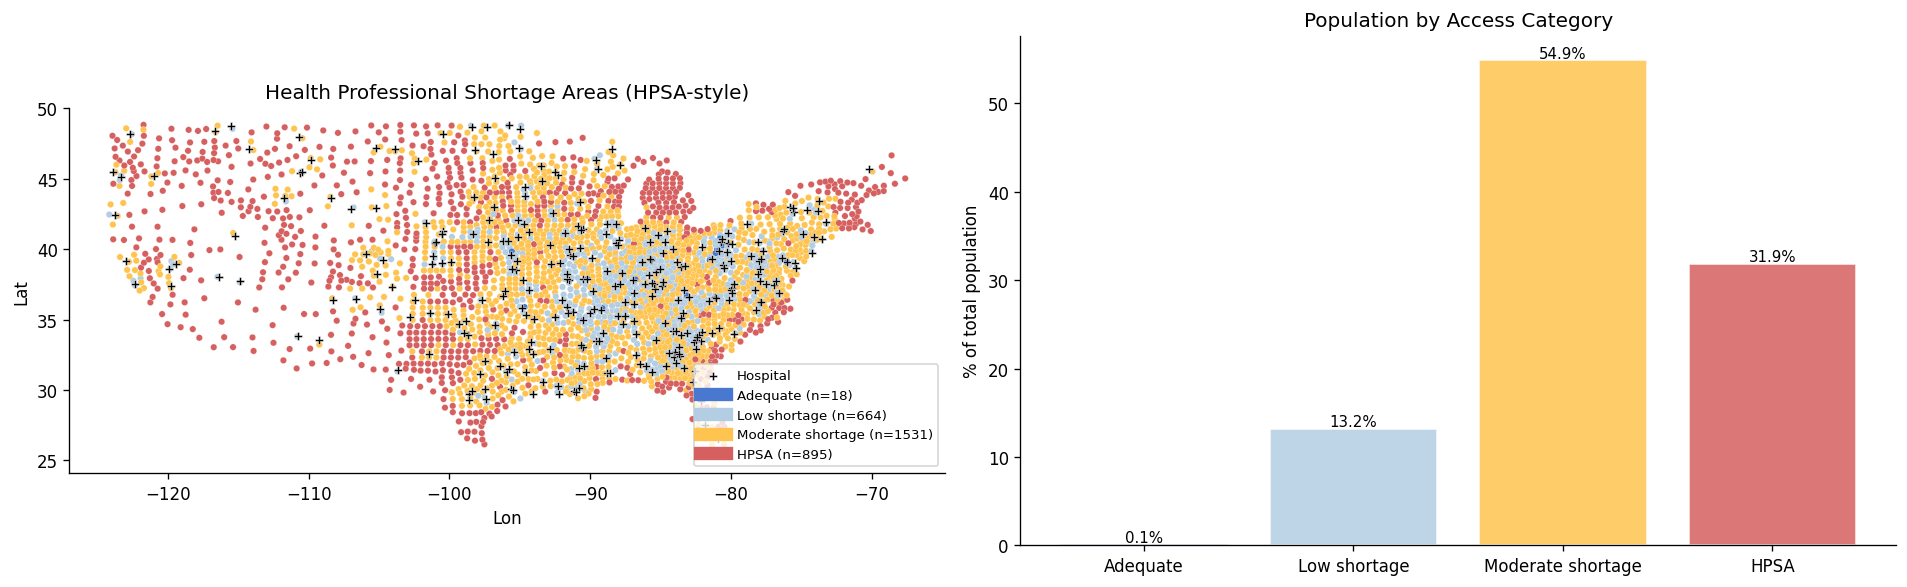

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings, os
warnings.filterwarnings("ignore"); os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})

HPSA_PPR_THRESHOLD = 0.286
HPSA_DIST_THRESHOLD = 3.5

score_ppr = 1 - (df.ppr_beds_per_1000 / df.ppr_beds_per_1000.quantile(0.9)).clip(0, 1)
score_dist = (df.dist_nearest_hosp / df.dist_nearest_hosp.quantile(0.9)).clip(0, 1)
score_2sfca = 1 - (df.access_2sfca / df.access_2sfca.quantile(0.9)).clip(0, 1)
score_uninsured = (df.pct_uninsured / df.pct_uninsured.quantile(0.9)).clip(0, 1)

df["hpsa_score"] = (score_ppr + score_dist + score_2sfca + score_uninsured) / 4
df["hpsa_status"] = pd.cut(df.hpsa_score, bins=[0, 0.25, 0.50, 0.75, 1.01],
                           labels=["Adequate", "Low shortage", "Moderate shortage", "HPSA"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
hpsa_colors = {"Adequate": "#4878CF", "Low shortage": "#B3CDE3",
               "Moderate shortage": "#FEC44F", "HPSA": "#D65F5F"}
colors_hpsa = [hpsa_colors[s] for s in df.hpsa_status]
axes[0].scatter(df.lon, df.lat, c=colors_hpsa, s=15, edgecolors="white", linewidth=0.15)
axes[0].scatter(df_hosp.lon, df_hosp.lat, marker="P", c="black", s=22, zorder=5,
                edgecolors="white", linewidths=0.3, label="Hospital")
axes[0].set_title("Health Professional Shortage Areas (HPSA-style)")
for label, color in hpsa_colors.items():
    n = (df.hpsa_status == label).sum()
    axes[0].plot([], [], "-", color=color, lw=8, label=f"{label} (n={n})")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_xlabel("Lon"); axes[0].set_ylabel("Lat"); axes[0].set_aspect("equal")

pop_by_status = df.groupby("hpsa_status", observed=True)["population"].sum()
pct_pop = pop_by_status / df.population.sum() * 100
axes[1].bar(pct_pop.index, pct_pop.values,
            color=[hpsa_colors[s] for s in pct_pop.index], alpha=0.85, edgecolor="white")
axes[1].set_ylabel("% of total population"); axes[1].set_title("Population by Access Category")
for i, (cat, val) in enumerate(pct_pop.items()):
    axes[1].text(i, val + 0.3, f"{val:.1f}%", ha="center", fontsize=9)
plt.tight_layout()


print("HPSA Analysis Summary:")
for status in ["Adequate", "Low shortage", "Moderate shortage", "HPSA"]:
    n_c = (df.hpsa_status == status).sum()
    pop_s = df.loc[df.hpsa_status == status, "population"].sum()
    pct = pop_s / df.population.sum() * 100
    print(f"  {status:22s}: {n_c:3d} counties | {pop_s:,} residents ({pct:.1f}%)")
df[["fips","county","state_abbr","hpsa_score","hpsa_status"]].to_csv("Data/hpsa_status.csv", index=False)


## 4. Disparities in Access by SES

In this section, we examine how disparities in healthcare access relate to socioeconomic status (SES) across counties.
We specifically ask: Do counties with higher poverty rates or more uninsured residents experience worse access to health services?
We'll use statistical analyses and visualizations to explore these relationships and summarize key findings.

In [5]:
# Do poorer counties have worse access?
from scipy.stats import pearsonr, spearmanr

access_corrs = {}
for access_metric, higher_is_better in [("ppr_beds_per_1000",True),
                                          ("dist_nearest_hosp",False),
                                          ("access_2sfca",True)]:
    r_poverty, p_pov = pearsonr(df.pct_poverty, df[access_metric])
    r_uniins, p_uni  = pearsonr(df.pct_uninsured, df[access_metric])
    if not higher_is_better:
        r_poverty, r_uniins = r_poverty, r_uniins  # for distance, positive r = worse access
    access_corrs[access_metric] = {"r_poverty":r_poverty,"p_poverty":p_pov,
                                    "r_uninsured":r_uniins,"p_uninsured":p_uni}

print("Access-Deprivation Correlations:")
print(f"{'Metric':25s} {'r(Poverty)':>12s} {'p':>8s} {'r(Uninsured)':>14s} {'p':>8s}")
print("-"*72)
for metric, vals in access_corrs.items():
    print(f"  {metric:23s} {vals['r_poverty']:>12.3f} {vals['p_poverty']:>8.4f} "
          f"{vals['r_uninsured']:>14.3f} {vals['p_uninsured']:>8.4f}")

# Concentration index (health equity measure)
def concentration_index(health, rank_var):
    n = len(health)
    rank = pd.Series(rank_var).rank() / n
    health_mean = health.mean()
    CI = 2 * np.cov(rank, health)[0,1] / health_mean
    return CI

ci_poverty_access = concentration_index(df.access_2sfca, df.pct_poverty)
print(f"\nConcentration Index (2SFCA access by poverty rank): {ci_poverty_access:.4f}")
print(f"  CI < 0 means better access is concentrated in RICHER areas (pro-rich inequality)")
print(f"  CI > 0 means better access is concentrated in POORER areas (pro-poor inequality)")
print(f"  CI = 0 means equal access distribution")


Access-Deprivation Correlations:
Metric                      r(Poverty)        p   r(Uninsured)        p
------------------------------------------------------------------------
  ppr_beds_per_1000              0.039   0.0277          0.011   0.5373
  dist_nearest_hosp             -0.116   0.0000         -0.039   0.0305
  access_2sfca                   0.041   0.0222          0.013   0.4584

Concentration Index (2SFCA access by poverty rank): 0.0300
  CI < 0 means better access is concentrated in RICHER areas (pro-rich inequality)
  CI > 0 means better access is concentrated in POORER areas (pro-poor inequality)
  CI = 0 means equal access distribution


## 5. Knowledge Check

1. **2SFCA gives county A score=0.82 and county B score=0.14. Both have the same distance to the nearest hospital. What could explain the large difference?**
   - Possible reasons: County A may have more healthcare providers per population, less competition for available providers, or more hospital/clinic capacity. County B may have more people sharing the same resources, fewer providers, or neighbors with poor access.

2. **The concentration index is -0.31. A health minister says "access is distributed equitably." Is this correct?**
   - No, this is incorrect. A negative concentration index indicates that better access is concentrated among richer counties, not distributed equitably. There is pro-rich inequality in access.

3. **Your HPSA analysis uses distance in degrees. Why is this problematic, and what would you use instead?**
   - Degree distances vary with latitude and are not constant lengths. Using degrees can introduce significant bias. It is better to use actual distances in kilometers or miles calculated with geographic projections or the Haversine formula.

4. **A large Academic Medical Centre opens in a rural county. How would each of the four access metrics change?**
   - The number of providers per 1,000 (ppr_beds_per_1000) would increase.
   - The distance to the nearest hospital (dist_nearest_hosp) would decrease for that county and possibly nearby counties.
   - 2SFCA access scores (access_2sfca) would increase for local residents.
   - HPSA scores would likely decrease, indicating less shortage.

5. **Implement a Gini coefficient for healthcare access to quantify inequality across all counties.**

   ```python
   def gini_coefficient(x):
       # x is a 1D numpy or pandas array, non-negative
       x = np.sort(np.array(x))
       n = len(x)
       cumulative_x = np.cumsum(x)
       gini = (n + 1 - 2 * np.sum(cumulative_x) / cumulative_x[-1]) / n
       return gini
   
   gini_access = gini_coefficient(df.access_2sfca)
   print(f"Gini coefficient for 2SFCA access: {gini_access:.3f}")
   ```
   Lower values indicate more equality; higher values, more inequality.


***
**Next → NB-08: Capstone — Spatial Health Inequity Atlas**
